# Analiza podatkov za 2024/25 in 2025/26 sezoni Premier lige

Podatki, ki so analizirani v tem zvezku so zbrani s [te spletne strani](https://www.11v11.com/)

Analiza vsebuje:
1. analizo tekem glede na gole (domači, gostje, povprečje, skupno, sezone,...)



In [277]:
import pandas as pd

tekme = pd.read_csv('podatki/tekme.csv')
strelci = pd.read_csv('podatki/strelci.csv')


In [278]:
tekme['datum'] = pd.to_datetime(tekme['datum'], format='%d %b %Y')

sezone = []
for datum in tekme['datum']:
    if datum.month >= 8:
        sezona = str(datum.year) + '/' + str(datum.year + 1)
    else:
        sezona = str(datum.year - 1) + '/' + str(datum.year)
    sezone.append(sezona)

tekme['sezona'] = sezone
tekme.head()

,datum,domaca_ekipa,goli_domaca,goli_gost,gostujoca_ekipa,kartoni_domaci,kartoni_gostje,rdeci_domaci,rdeci_gostje,rumeni_domaci,rumeni_gostje,strelci_domaci,strelci_gostje,sezona
0,2025-08-16,Aston Villa,0,0,Newcastle United,"Boubacar Kamara 58' (Y), Ezri Konsa 66' (R)",Joelinton 45' (Y),1,0,1,1,NaN,NaN,2025/2026
1,2025-08-17,Chelsea,0,0,Crystal Palace,"Reece James 24' (Y), Estêvão 74' (Y)","Daniel Muñoz 28' (Y), Jean-Philippe Mateta 33'...",0,0,2,3,NaN,NaN,2025/2026
2,2025-08-17,Manchester United,0,1,Arsenal,Patrick Dorgu 85' (Y),"Riccardo Calafiori 42' (Y), David Raya 85' (Y)...",0,0,1,4,NaN,Riccardo Calafiori (Defender) 13',2025/2026
3,2025-08-16,Brighton and Hove Albion,1,1,Fulham,"Kaoru Mitoma 60' (Y), Ferdi Kadioğlu 73' (Y), ...","Calvin Bassey 31' (Y), Tom Cairney 90+3' (Y), ...",0,0,3,3,NaN,Rodrigo Muniz (Forward) 90+6',2025/2026
4,2025-08-18,Leeds United,1,0,Everton,NaN,"Tim Iroegbunam 56' (Y), Carlos Alcaraz 63' (Y)",0,0,0,2,NaN,NaN,2025/2026


In [279]:
len(tekme)

760

In [280]:
tekme['datum'] = pd.to_datetime(tekme['datum'], format='%d %b %Y')



### 1. Koliko tekem je bilo odigranih v vsaki sezoni


In [281]:
def doloci_sezono(datum):
    if datum.month >= 8:
        sezona = str(datum.year) + '/' + str(datum.year + 1)
    else:
        sezona = str(datum.year - 1) + '/' + str(datum.year)
    return sezona

tekme['sezona'] = tekme['datum'].apply(doloci_sezono)
tekme['sezona'].value_counts()

sezona
2025/2026    380
2024/2025    380
Name: count, dtype: int64

V vsaki sezoni je bilo odigranih natanko 380 iger (kar ni presenetljivo (in je precej očitno)).

# 1. Analiza tekem glede na gole

### 1.1 Goli - Domači

Oglejmo si število golov, ki jih je dosegla posamezna ekipa, ko so igrali na domačih tleh.

In [282]:
goli_doma = tekme.groupby('domaca_ekipa')['goli_domaca'].sum()
goli_doma = goli_doma.sort_values(ascending=False)


tabela_golov_domaci = pd.DataFrame({
    'ekipa': goli_doma.index,
    'goli':goli_doma.values
})

tabela_golov_domaci

,ekipa,goli
0,Manchester City,88
1,Liverpool,76
2,Arsenal,76
3,Newcastle United,76
4,Brentford,73
5,Aston Villa,66
6,Manchester United,62
7,Chelsea,61
8,Brighton and Hove Albion,60
9,Fulham,57


Na domačih tleh je torej najbolj uspešen Manchester City. Oglejmo si še skupno število golov vseh ekip, ko so igrale na domačem terenu:

In [283]:
skupni_goli_domacih = goli_doma.sum()
skupni_goli_domacih

np.int64(1155)

Skupno število takšnih golov je torej 1155

### 1.2 Goli - Gostujoči

Sedaj si poglejmo število golov, ki so jih dosegle posamezne ekipe na položaju gostujočih

In [284]:
goli_gost = tekme.groupby('gostujoca_ekipa')['goli_gost'].sum()
goli_gost = goli_gost.sort_values(ascending=False)

tabela_golov_gost = pd.DataFrame({
    'ekipa':goli_gost.index,
    'goli':goli_gost.values
})

tabela_golov_gost

,ekipa,goli
0,Liverpool,73
1,Arsenal,64
2,AFC Bournemouth,64
3,Manchester City,61
4,Chelsea,61
5,Nottingham Forest,60
6,Brighton and Hove Albion,58
7,Tottenham Hotspur,55
8,Manchester United,51
9,Crystal Palace,49


Tokrat je na vrhu Liverpool.

In [285]:
skupni_goli_gosti = goli_gost.sum()
skupni_goli_gosti

np.int64(1005)

Skupno število vseh golov, doseženih na položaju gostov je torej 1005, kar je 150 manj kot na položaju domačih. Torej so ekipe bolj uspešne, ko igrajo na poznanem terenu (očitno).

### 1.3 Goli - Skupno



Bolj smiselno je obravnavati število golov za vsako sezono posebaj. Spodnji diagram prikazuje število golov za vsako sezono in klub posebaj

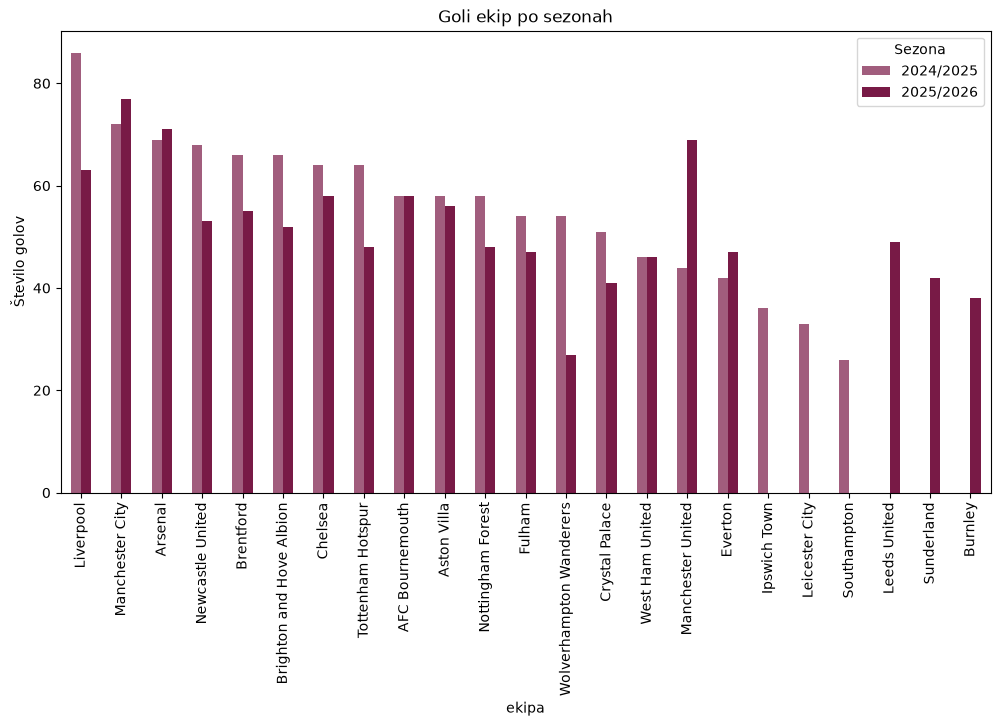

In [286]:
import matplotlib.pyplot as plt

domace_vrstice = tekme[['domaca_ekipa', 'sezona', 'goli_domaca']].copy()
domace_vrstice.columns = ['ekipa', 'sezona', 'goli']

gostujoce_vrstice = tekme[['gostujoca_ekipa', 'sezona', 'goli_gost']].copy()
gostujoce_vrstice.columns = ['ekipa', 'sezona', 'goli']

vse_vrstice = pd.concat([domace_vrstice, gostujoce_vrstice])

goli_po_ekipi_sezoni = vse_vrstice.groupby(['ekipa', 'sezona'])['goli'].sum()
goli_po_ekipi_sezoni = goli_po_ekipi_sezoni.sort_values(ascending=False)
goli_po_ekipi_sezoni.head(20)

tabela_po_sezonah = goli_po_ekipi_sezoni.unstack()

tabela_po_sezonah = tabela_po_sezonah.fillna(0).astype(int)

tabela_po_sezonah = tabela_po_sezonah.sort_values(
    by=tabela_po_sezonah.columns.tolist(),
    ascending=False
)

tabela_po_sezonah

tabela_po_sezonah.plot(kind='bar', figsize=(12, 6), color =['#a15d7d', '#781a46'])

plt.xlabel('ekipa')
plt.ylabel('Število golov')
plt.title('Goli ekip po sezonah')
plt.xticks(rotation=90)
plt.legend(title='Sezona')
plt.show() 

Opomba: v nekaterih stolpcih vrednost 0 (zaradi preglednosti) nadomešča NaN, kar pomeni, da ekipa v tisti sezoni ni igrala.

Skupno število golov v obeh sezonah za vsako ekipo:

In [287]:
goli_skupaj = goli_doma.add(goli_gost, fill_value=0)
goli_skupaj = goli_skupaj.sort_values(ascending=False)
goli_skupaj.index.name = 'ekipa'

tabela_golov_skupaj = pd.DataFrame({
    'ekipa': goli_skupaj.index,
    'goli skupno':goli_skupaj.values
})

tabela_golov_skupaj

,ekipa,goli skupno
0,Liverpool,149
1,Manchester City,149
2,Arsenal,140
3,Chelsea,122
4,Newcastle United,121
5,Brentford,121
6,Brighton and Hove Albion,118
7,AFC Bournemouth,116
8,Aston Villa,114
9,Manchester United,113


### 1.4. Koliko golov je v povprečju vsaka ekipa dosegla na eni domači tekmi?

In [288]:
povp_doma = tekme.groupby('domaca_ekipa')['goli_domaca'].mean()
povp_doma = povp_doma.sort_values(ascending=False)
povp_doma = round(povp_doma, 2)

tabela_povp_doma = pd.DataFrame({
    'ekipa':povp_doma.index,
    'povprečje golov na eni tekmi':povp_doma.values
})

tabela_povp_doma

,ekipa,povprečje golov na eni tekmi
0,Manchester City,2.32
1,Liverpool,2.00
2,Arsenal,2.00
3,Newcastle United,2.00
4,Brentford,1.92
5,Aston Villa,1.74
6,Manchester United,1.63
7,Chelsea,1.61
8,Brighton and Hove Albion,1.58
9,Leeds United,1.53


In [289]:
povp_gost = tekme.groupby('gostujoca_ekipa')['goli_gost'].mean()
povp_gost = povp_gost.sort_values(ascending=False)
povp_gost = round(povp_gost, 2)

tabela_povp_gost = pd.DataFrame({
    'ekipa': povp_gost.index,
    'povprečje golov na eni tekmi':povp_gost.values
})

tabela_povp_gost

,ekipa,povprečje golov na eni tekmi
0,Liverpool,1.92
1,Arsenal,1.68
2,AFC Bournemouth,1.68
3,Manchester City,1.61
4,Chelsea,1.61
5,Nottingham Forest,1.58
6,Brighton and Hove Albion,1.53
7,Tottenham Hotspur,1.45
8,Manchester United,1.34
9,Crystal Palace,1.29


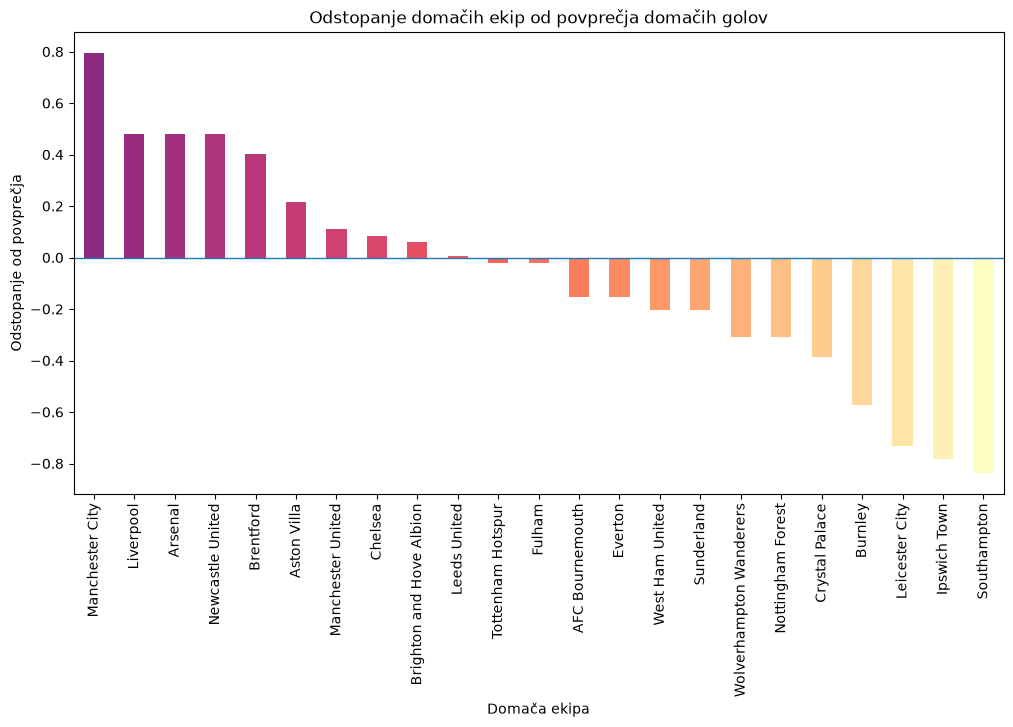

In [290]:
import matplotlib.cm as cm  
import numpy as np

povp_doma = tekme.groupby('domaca_ekipa')['goli_domaca'].mean()
povprecje_doma = tekme['goli_domaca'].mean()

odstopanje_doma = povp_doma - povprecje_doma
odstopanje_doma = odstopanje_doma.sort_values(ascending=False)

barve = cm.magma(np.linspace(0.4, 1, len(odstopanje_doma)))

odstopanje_doma.plot(kind='bar', figsize=(12, 6), color=barve)

plt.axhline(0, linewidth=1)
plt.xlabel('Domača ekipa')
plt.ylabel('Odstopanje od povprečja')
plt.title('Odstopanje domačih ekip od povprečja domačih golov')
plt.xticks(rotation=90)
plt.show()

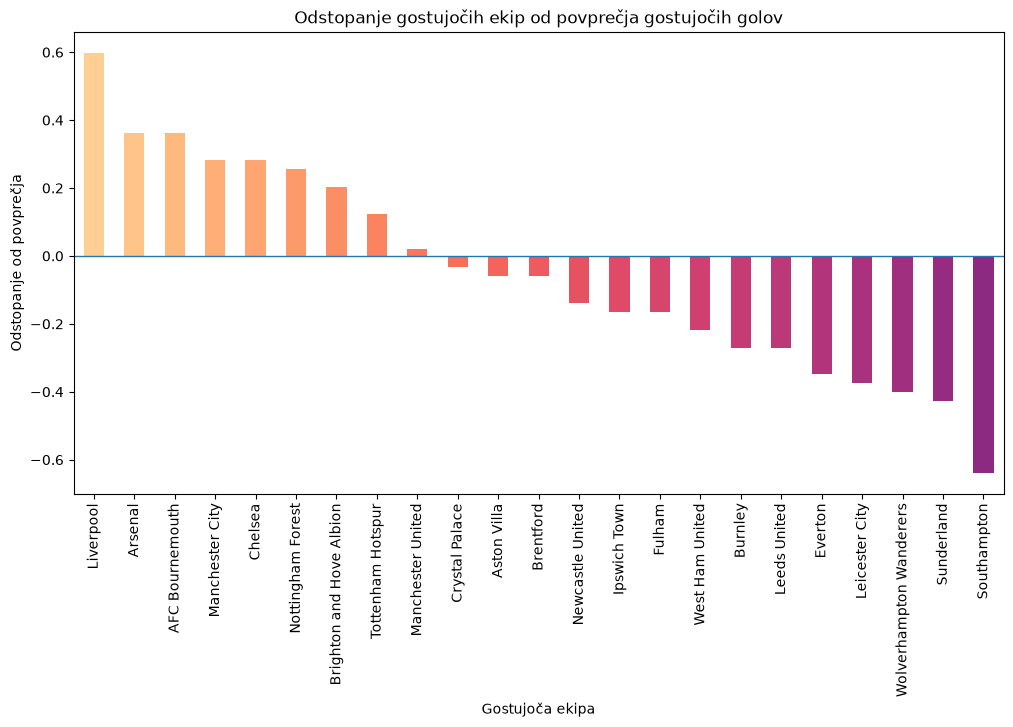

In [291]:
povp_gost = tekme.groupby('gostujoca_ekipa')['goli_gost'].mean()
povprecje_gost = tekme['goli_gost'].mean()

odstopanje_gost = povp_gost - povprecje_gost
odstopanje_gost = odstopanje_gost.sort_values(ascending=False)

barve = cm.magma.reversed()(np.linspace(0.1, 0.6, len(odstopanje_gost)))

odstopanje_gost.plot(kind='bar', figsize=(12, 6), color=barve)

plt.axhline(0, linewidth=1)
plt.xlabel('Gostujoča ekipa')
plt.ylabel('Odstopanje od povprečja')
plt.title('Odstopanje gostujočih ekip od povprečja gostujočih golov')
plt.xticks(rotation=90)
plt.show()

Zmaga domačih: 317 - 41.7 %
Zmaga gostov: 246 - 32.4 %
Neodločeno: 197 - 25.9 %


<Axes: >

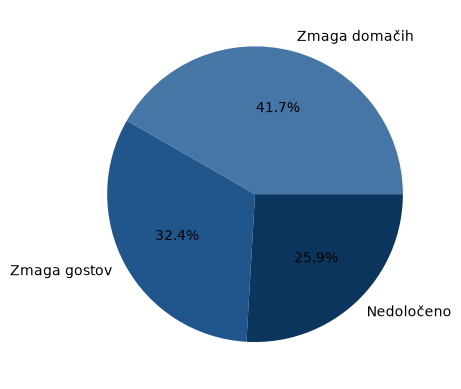

In [292]:
izidi = []

for i in range(len(tekme)):
    doma_goli = tekme['goli_domaca'][i]
    gost_goli = tekme['goli_gost'][i]

    if doma_goli > gost_goli:
        izid = 'Zmaga domačih'
    
    elif doma_goli < gost_goli:
        izid = 'Zmaga gostov'
    
    else:
        izid = 'Nedoločeno'
    
    izidi.append(izid)

tekme['izid'] = izidi

stevilo_domaci = 0
stevilo_gostje = 0
stevilo_nedolocen = 0

for izid in izidi:
    if izid == 'Zmaga domačih':
        stevilo_domaci += 1
    elif izid == 'Zmaga gostov':
        stevilo_gostje += 1
    else:
        stevilo_nedolocen += 1

skupaj = len(izidi)

print("Zmaga domačih:", stevilo_domaci, "-", round(stevilo_domaci / skupaj * 100, 1), "%")
print("Zmaga gostov:", stevilo_gostje, "-", round(stevilo_gostje / skupaj * 100, 1), "%")
print("Neodločeno:", stevilo_nedolocen, "-", round(stevilo_nedolocen / skupaj * 100, 1), "%")

tekme['izid'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#4676a6', '#20568c', '#0c355e']
    
)

Domači imajo večji delež zmag, torej imajo očitno nekakšno prednost.

### 1.5. Delež vseh zadetkov glede na pozicijo igralca

Kako pozicija igralca vpliva na število zadetkov? Očitno je, da bo največje število dosegel igralec na poziciji napadalca(forward) in vezista(midfielder).

<Axes: >

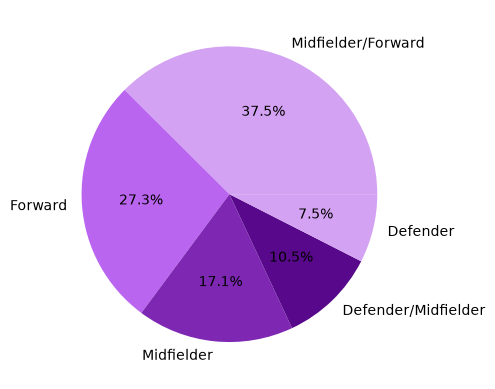

In [293]:
import re

vse_pozicije = []

for besedilo in tekme['strelci_domaci'].dropna():
    vse_pozicije += re.findall(r'\(([A-Za-z/ ]+)\)', besedilo)

for besedilo in tekme['strelci_gostje'].dropna():
    vse_pozicije += re.findall(r'\(([A-Za-z/ ]+)\)', besedilo)

len(vse_pozicije)

pozicije_stevilo = pd.Series(vse_pozicije).value_counts()
pozicije_delez = pd.Series(vse_pozicije).value_counts(normalize=True) * 100

povzetek_pozicij = pd.DataFrame({
    'stevilo_golov': pozicije_stevilo,
    'delez (%)': pozicije_delez.round(1)
})

povzetek_pozicij

pozicije_stevilo.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#d4a2f2', '#ba65f0', '#7d27b3', '#58088a']
     )

Rezultati niso ravno presenetljivi

### 1.6. V katerem delu igre so najbolj pogosti goli?

0-15 min: 254
16-30 min: 254
31-45 min: 370
46-60 min: 304
61-75 min: 298
76-90+ min: 461


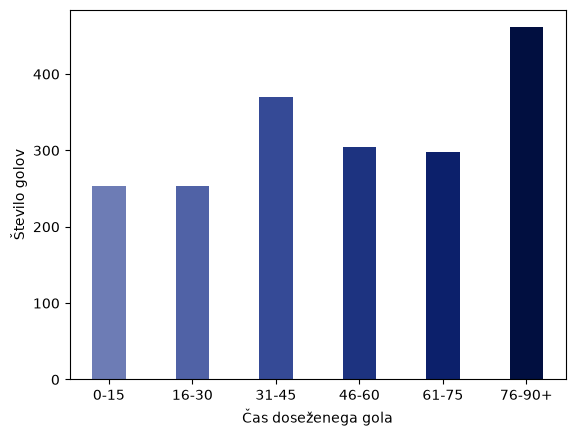

In [294]:
vse_minute = []

for besedilo in tekme['strelci_domaci']:
    if pd.isna(besedilo):
        continue
    najdene = re.findall(r"(\d{1,3})(?:\+\d{1,2})?'", besedilo)
    for m in najdene:
        vse_minute.append(int(m))

for besedilo in tekme['strelci_gostje']:
    if pd.isna(besedilo):
        continue
    najdene = re.findall(r"(\d{1,3})(?:\+\d{1,2})?'", besedilo)
    for m in najdene:
        vse_minute.append(int(m))

len(vse_minute)


stevilo_0_15 = 0
stevilo_16_30 = 0
stevilo_31_45 = 0
stevilo_46_60 = 0
stevilo_61_75 = 0
stevilo_76_90 = 0

for minuta in vse_minute:
    if minuta <= 15:
        stevilo_0_15 += 1
    elif minuta <= 30:
        stevilo_16_30 += 1
    elif minuta <= 45:
        stevilo_31_45 += 1
    elif minuta <= 60:
        stevilo_46_60 += 1
    elif minuta <= 75:
        stevilo_61_75 += 1
    else:
        stevilo_76_90 += 1

print("0-15 min:", stevilo_0_15)
print("16-30 min:", stevilo_16_30)
print("31-45 min:", stevilo_31_45)
print("46-60 min:", stevilo_46_60)
print("61-75 min:", stevilo_61_75)
print("76-90+ min:", stevilo_76_90)

import matplotlib.pyplot as plt

minute = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90+']
goli = [stevilo_0_15, stevilo_16_30, stevilo_31_45,
        stevilo_46_60, stevilo_61_75, stevilo_76_90]

barve =['#6d7cb5', '#5062a6', '#354a96', '#1d3380', '#0c206b', '#010f40']


plt.xlabel('Čas doseženega gola')
plt.ylabel('Število golov')
plt.bar( minute, goli, color=barve, width=0.4 )
plt.show()

Zaradi stresa in napetosti v zadnjih minutah igre, ni presenetljivo, da je večina golov dosežena ravno takrat.

## 2. Lestvica strelcev


Po pregledu golov glede na klub bi si lahko ogledali tudi strelce, ki so za njih odgovorni.

In [295]:
import pandas as pd
strelci = pd.read_csv('podatki/strelci.csv')


lestvica = strelci.reset_index(drop=True)
lestvica

,ekipa,goli,ime
0,Manchester City,27,Erling Haaland
1,Brentford,22,Igor Thiago
2,Aston Villa,16,Ollie Watkins
3,Nottingham Forest,15,Morgan Gibbs-White
4,Leeds United,14,Dominic Calvert-Lewin
5,AFC Bournemouth,13,Eli Kroupi
6,Crystal Palace,12,Jean-Philippe Mateta
7,Liverpool,11,Hugo Ekitike
8,Chelsea,10,Enzo Fernández
9,Everton,9,Beto


Opomba: Ponekod se isto ime pojavi dvakrat, saj je bil igralec med najboljšimi stelci v obeh sezonah

# 3. Analiza tekem glede na rumene in rdeče kartone

## 3.1 Povprečno število rdečih in rumenih kartonov po ekipah

In [296]:
ekipe = []
imena_ekip = []
seznam_rumenih = []
seznam_rdecih = []
seznam_razmerij = []

for ekipa in tekme['domaca_ekipa']:
    if ekipa not in ekipe:
        ekipe.append(ekipa)

for ekipa in tekme['gostujoca_ekipa']:
    if ekipa not in ekipe:
        ekipe.append(ekipa)

for ekipa in ekipe:
    rumeni_skupaj = 0
    rdeci_skupaj = 0
    stevilo_tekem = 0

    for i in range(len(tekme)):
        if tekme['domaca_ekipa'][i] == ekipa:
            rumeni_skupaj += tekme['rumeni_domaci'][i]
            rdeci_skupaj += tekme['rdeci_domaci'][i]
            stevilo_tekem += 1

        if tekme['gostujoca_ekipa'][i] == ekipa:
            rumeni_skupaj += tekme['rumeni_gostje'][i]
            rdeci_skupaj += tekme['rdeci_gostje'][i]
            stevilo_tekem += 1

    povp_rumeni = rumeni_skupaj / stevilo_tekem
    povp_rdeci = rdeci_skupaj / stevilo_tekem
    razmerje = povp_rdeci / povp_rumeni

    imena_ekip.append(ekipa)
    seznam_rumenih.append(round(povp_rumeni, 2))
    seznam_rdecih.append(round(povp_rdeci, 2))
    seznam_razmerij.append(round(razmerje, 3))


tabela_kartonov = pd.DataFrame({
    'ekipa': imena_ekip,
    'povprecno rumenih': seznam_rumenih,
    'povprecno rdecih': seznam_rdecih,
    'razmerje':seznam_razmerij

})

tabela_kartonov

,ekipa,povprecno rumenih,povprecno rdecih,razmerje
0,Aston Villa,1.76,0.07,0.037
1,Chelsea,2.63,0.13,0.050
2,Manchester United,1.97,0.08,0.040
3,Brighton and Hove Albion,2.14,0.04,0.018
4,Leeds United,1.68,0.03,0.016
5,Sunderland,2.18,0.08,0.036
6,Tottenham Hotspur,2.28,0.07,0.029
7,Wolverhampton Wanderers,2.07,0.07,0.032
8,Nottingham Forest,1.96,0.04,0.020
9,AFC Bournemouth,2.43,0.07,0.027


Kot zanimiviost si lahko ogledamo, če obstaja kakšna povezava med uspešnostjo ekipe (merjena glede na število golov) in razmerjem med prejetimi rdečimi in rumenimi kartoni.

In [297]:

seznam_ekip = []
seznam_golov = []
seznam_rumenih = []
seznam_rdecih = []
seznam_razmerij = []

for i in range(len(tabela_kartonov)):

    ime_ekipe = tabela_kartonov['ekipa'][i]

    seznam_ekip.append(ime_ekipe)
    seznam_golov.append(goli_skupaj[ime_ekipe])
    seznam_rumenih.append(tabela_kartonov['povprecno rumenih'][i])
    seznam_rdecih.append(tabela_kartonov['povprecno rdecih'][i])
    seznam_razmerij.append(tabela_kartonov['razmerje'][i])

skupna_tabela = pd.DataFrame({
    'ekipa': seznam_ekip,
    'goli skupaj': seznam_golov,
    'povprecno rumenih': seznam_rumenih,
    'povprecno rdecih': seznam_rdecih,
    'razmerje rdeci rumeni': seznam_razmerij
})

skupna_tabela = skupna_tabela.sort_values('goli skupaj', ascending=False)

skupna_tabela



,ekipa,goli skupaj,povprecno rumenih,povprecno rdecih,razmerje rdeci rumeni
10,Liverpool,149,1.63,0.05,0.032
15,Manchester City,149,1.66,0.03,0.016
18,Arsenal,140,1.59,0.08,0.050
1,Chelsea,122,2.63,0.13,0.050
11,Brentford,121,1.72,0.03,0.015
17,Newcastle United,121,1.79,0.05,0.029
3,Brighton and Hove Albion,118,2.14,0.04,0.018
9,AFC Bournemouth,116,2.43,0.07,0.027
0,Aston Villa,114,1.76,0.07,0.037
2,Manchester United,113,1.97,0.08,0.040


Za boljšo preglednost so podatki iz zgornje tabele prikazani grafično. Na grafu so ekipe razvrščene po uspešnosti (od najbolj uspešne do najmanj).

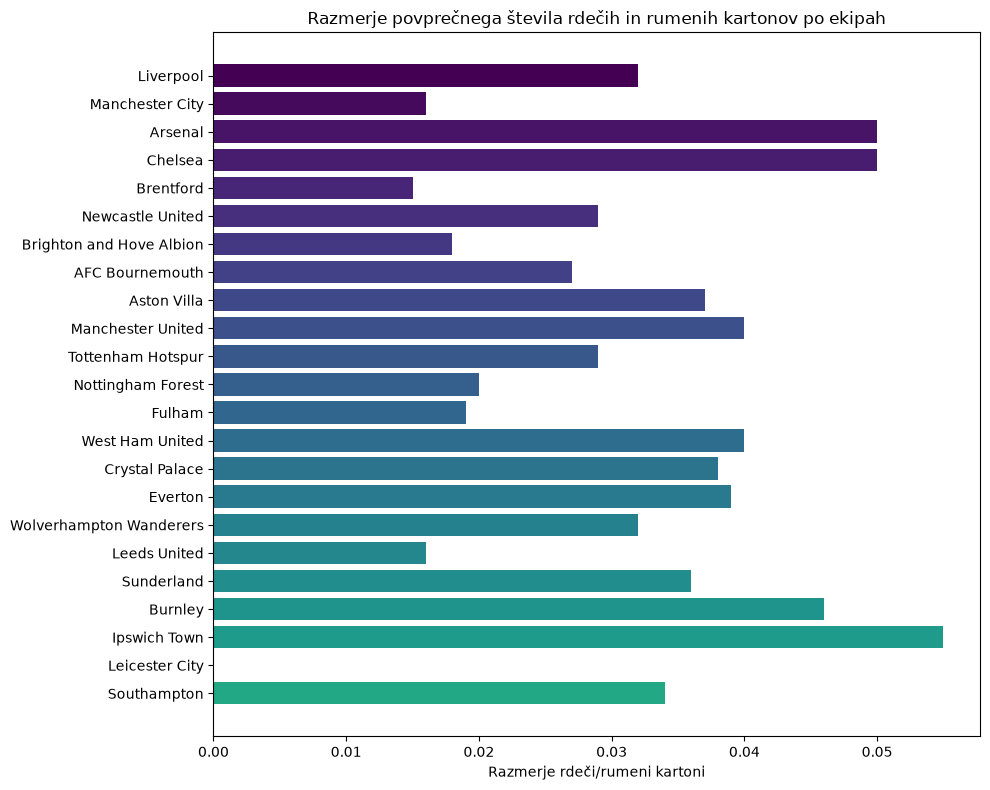

In [298]:
import matplotlib.cm as cm
import numpy as np

tabela_sortirana = skupna_tabela.copy()

tabela_sortirana['goli skupaj'] = tabela_sortirana['ekipa'].map(goli_skupaj)

tabela_sortirana = tabela_sortirana.sort_values('goli skupaj', ascending=True)

nove_barve = cm.viridis.reversed()
barve = nove_barve(np.linspace(0.4, 1, len(tabela_sortirana)))

plt.figure(figsize=(10, 8))

plt.barh(
    tabela_sortirana['ekipa'],
    tabela_sortirana['razmerje rdeci rumeni'],
    color=barve
)

plt.xlabel('Razmerje rdeči/rumeni kartoni')
plt.title('Razmerje povprečnega števila rdečih in rumenih kartonov po ekipah')
plt.tight_layout()
plt.show()

Razvidno je, da ni nekih stalnih vzorcev/ povezave med uspešnostjo ekipe in razmerjem. Opazno negativno odstopa samo par ekip.

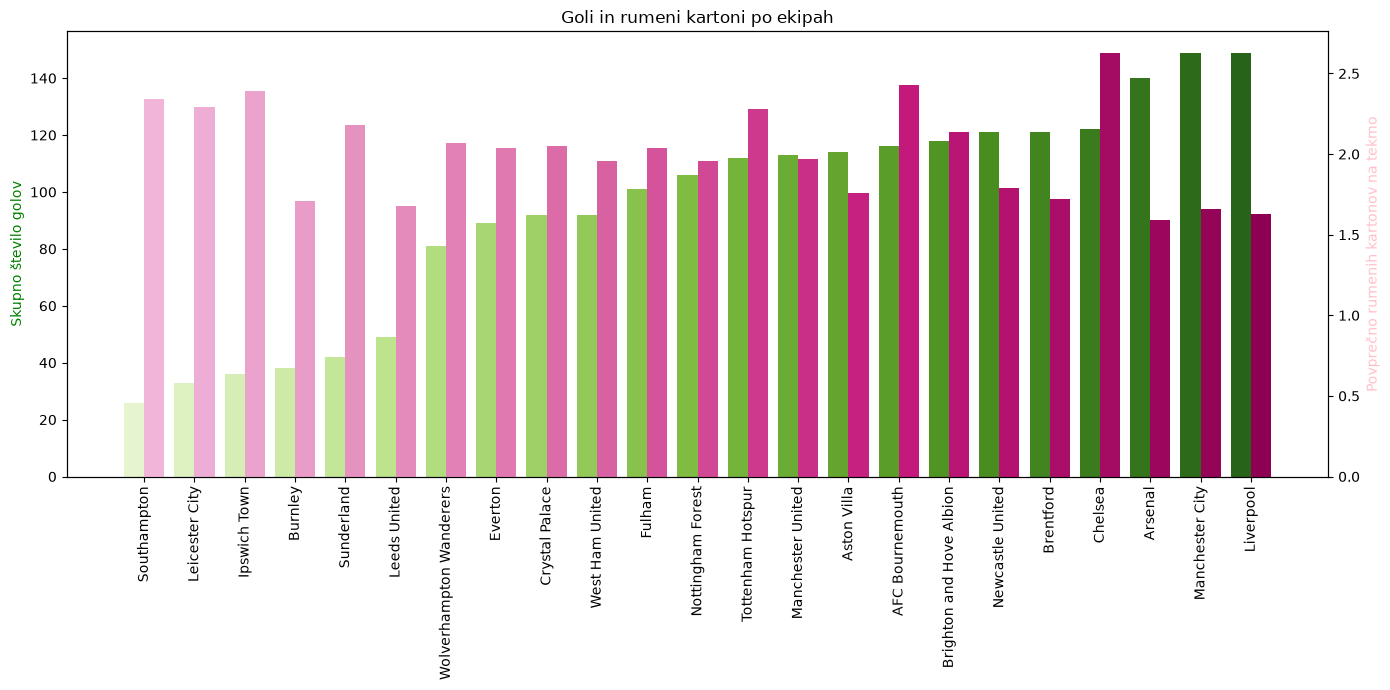

In [299]:
import matplotlib.cm as cm  
import numpy as np

skupna_tabela = skupna_tabela.sort_values('goli skupaj', ascending=True).reset_index(drop=True)

x = np.arange(len(skupna_tabela))
sirina = 0.4

fig, ax1 = plt.subplots(figsize=(14, 7))

barve_kartoni1 = cm.PiYG.reversed()

barve_goli = cm.PiYG(np.linspace(0.6, 1, len(skupna_tabela)))
barve_kartoni = barve_kartoni1(np.linspace(0.7, 1, len(skupna_tabela)))

ax1.bar(x - sirina/2, skupna_tabela['goli skupaj'], width=sirina, color=barve_goli, label='Goli')
ax1.set_ylabel('Skupno število golov', color='green')
ax1.set_xticks(x)
ax1.set_xticklabels(skupna_tabela['ekipa'], rotation=90)

ax2 = ax1.twinx()
ax2.bar(x + sirina/2, skupna_tabela['povprecno rumenih'], width=sirina, color=barve_kartoni, label='Rumeni kartoni')
ax2.set_ylabel('Povprečno rumenih kartonov na tekmo', color='pink')

plt.title('Goli in rumeni kartoni po ekipah')
fig.tight_layout()
plt.show()

V številu rumenih kartonov ni večjih odstopanj, zanimivo pa je, da imajo tri najbolj uspešne ekipe najmanjše povprečno število rumenih kartonov na tekmo.

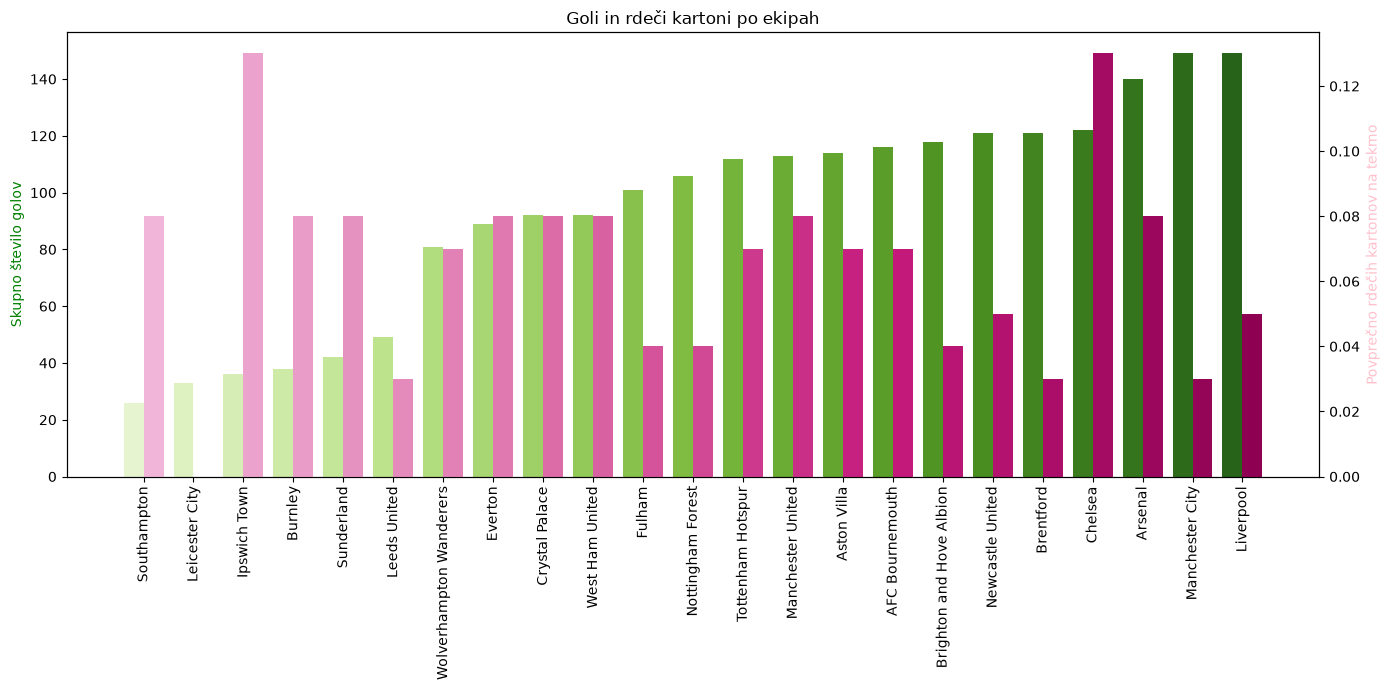

In [300]:
import matplotlib.cm as cm  
import numpy as np

skupna_tabela = skupna_tabela.sort_values('goli skupaj', ascending=True).reset_index(drop=True)

x = np.arange(len(skupna_tabela))
sirina = 0.4

fig, ax1 = plt.subplots(figsize=(14, 7))

barve_kartoni1 = cm.PiYG.reversed()

barve_goli = cm.PiYG(np.linspace(0.6, 1, len(skupna_tabela)))
barve_kartoni = barve_kartoni1(np.linspace(0.7, 1, len(skupna_tabela)))

ax1.bar(x - sirina/2, skupna_tabela['goli skupaj'], width=sirina, color=barve_goli, label='Goli')
ax1.set_ylabel('Skupno število golov', color='green')
ax1.set_xticks(x)
ax1.set_xticklabels(skupna_tabela['ekipa'], rotation=90)

ax2 = ax1.twinx()
ax2.bar(x + sirina/2, skupna_tabela['povprecno rdecih'], width=sirina, color=barve_kartoni, label='Rdeči kartoni')
ax2.set_ylabel('Povprečno rdečih kartonov na tekmo', color='pink')

plt.title('Goli in rdeči kartoni po ekipah')
fig.tight_layout()
plt.show()

Pri povprečnem številu rdečih kartonov na tekmo pa je graf precej bolj razgiban brez ustaljenih vzorcev.

## 3.3. V katerem delu igre so najbolj pogosti rdeči/rumeni kartoni?

In [301]:
import re

rumene_minute = []
rdece_minute = []

for stolpec in ['kartoni_domaci', 'kartoni_gostje']:
    for besedilo in tekme[stolpec]:

        if pd.isna(besedilo):
            continue

        
        najdene = re.findall(r"(\d{1,3})(?:\+\d{1,2})?' \(([YR])\)", str(besedilo))

        for minuta, vrsta in najdene:

            minuta = int(minuta)

            if vrsta == "Y":
                rumene_minute.append(minuta)
            elif vrsta == "R":
                rdece_minute.append(minuta)



rumeni_0_15 = 0
rumeni_16_30 = 0
rumeni_31_45 = 0
rumeni_46_60 = 0
rumeni_61_75 = 0
rumeni_76_90 = 0

for minuta in rumene_minute:

    if minuta <= 15:
        rumeni_0_15 += 1
    elif minuta <= 30:
        rumeni_16_30 += 1
    elif minuta <= 45:
        rumeni_31_45 += 1
    elif minuta <= 60:
        rumeni_46_60 += 1
    elif minuta <= 75:
        rumeni_61_75 += 1
    else:
        rumeni_76_90 += 1




rdeci_0_15 = 0
rdeci_16_30 = 0
rdeci_31_45 = 0
rdeci_46_60 = 0
rdeci_61_75 = 0
rdeci_76_90 = 0

for minuta in rdece_minute:

    if minuta <= 15:
        rdeci_0_15 += 1
    elif minuta <= 30:
        rdeci_16_30 += 1
    elif minuta <= 45:
        rdeci_31_45 += 1
    elif minuta <= 60:
        rdeci_46_60 += 1
    elif minuta <= 75:
        rdeci_61_75 += 1
    else:
        rdeci_76_90 += 1


print("RUMENI KARTONI:")
print("0-15 min:", rumeni_0_15)
print("16-30 min:", rumeni_16_30)
print("31-45 min:", rumeni_31_45)
print("46-60 min:", rumeni_46_60)
print("61-75 min:", rumeni_61_75)
print("76-90+ min:", rumeni_76_90)

print()
print("RDEČI KARTONI:")
print("0-15 min:", rdeci_0_15)
print("16-30 min:", rdeci_16_30)
print("31-45 min:", rdeci_31_45)
print("46-60 min:", rdeci_46_60)
print("61-75 min:", rdeci_61_75)
print("76-90+ min:", rdeci_76_90)

intervali_oznake = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90+']

rumeni_stevilke = [rumeni_0_15, rumeni_16_30, rumeni_31_45, rumeni_46_60, rumeni_61_75, rumeni_76_90]
rdeci_stevilke = [rdeci_0_15, rdeci_16_30, rdeci_31_45, rdeci_46_60, rdeci_61_75, rdeci_76_90]

RUMENI KARTONI:
0-15 min: 135
16-30 min: 282
31-45 min: 574
46-60 min: 454
61-75 min: 531
76-90+ min: 1066

RDEČI KARTONI:
0-15 min: 2
16-30 min: 6
31-45 min: 29
46-60 min: 8
61-75 min: 19
76-90+ min: 32


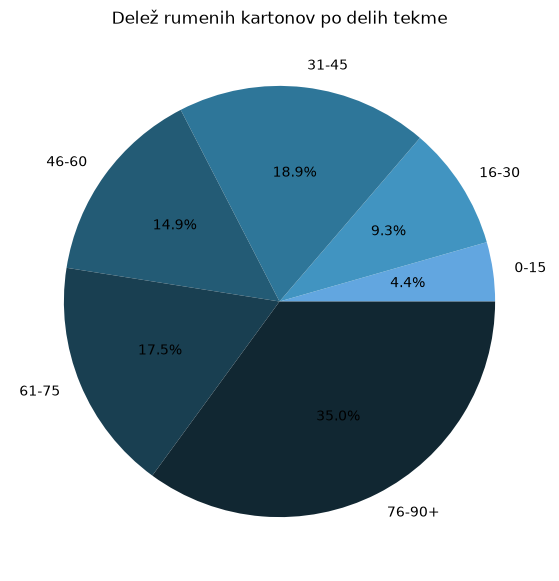

In [302]:
plt.figure(figsize=(7, 7))
plt.pie(rumeni_stevilke, labels=intervali_oznake, autopct='%1.1f%%', colors=plt.cm.berlin(np.linspace(0.1, 0.4, 6)))
plt.title('Delež rumenih kartonov po delih tekme')
plt.show()

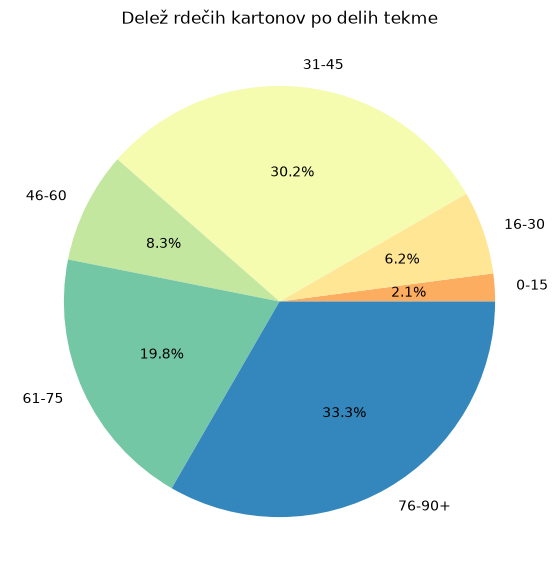

In [303]:
plt.figure(figsize=(7, 7))
plt.pie(rdeci_stevilke, labels=intervali_oznake, autopct='%1.1f%%', colors=plt.cm.Spectral(np.linspace(0.3, 0.9, 6)))
plt.title('Delež rdečih kartonov po delih tekme')
plt.show()

Kot pričakovano je največ rdečih in rumenih kartonov v zadnjem delu igre in podaljških.

## 4. Odigrane tekme, zmage, porazi, dani goli, prejeti goli, točke 

Za lažjo preglednost sestavimo razpredelnico, ki za vsak klub poleg izida igre in števila golov izračuna še število točk. Vsaka zmaga je vredna 3 točke, remi 1 točko in poraz 0 točk

In [304]:
ekipe = []

for vrstica in tekme.itertuples():
    if vrstica.domaca_ekipa not in ekipe:
        ekipe.append(vrstica.domaca_ekipa)
    if vrstica.gostujoca_ekipa not in ekipe:
        ekipe.append(vrstica.gostujoca_ekipa)

uspesnost = []

for ekipa in ekipe:
    tekme_ekipe = 0
    zmage = 0
    remiji = 0
    porazi = 0
    dani_goli = 0
    prejeti_goli = 0

    for vrstica in tekme.itertuples():

        if vrstica.domaca_ekipa == ekipa:
            tekme_ekipe += 1
            dani_goli += vrstica.goli_domaca
            prejeti_goli += vrstica.goli_gost

            if vrstica.goli_domaca > vrstica.goli_gost:
                zmage += 1
            elif vrstica.goli_domaca == vrstica.goli_gost:
                remiji += 1
            else:
                porazi += 1

        elif vrstica.gostujoca_ekipa == ekipa:
            tekme_ekipe += 1
            dani_goli += vrstica.goli_gost
            prejeti_goli += vrstica.goli_domaca

            if vrstica.goli_gost > vrstica.goli_domaca:
                zmage += 1
            elif vrstica.goli_gost == vrstica.goli_domaca:
                remiji += 1
            else:
                porazi += 1

    
    tocke = zmage * 3 + remiji
    povprecje_golov = dani_goli / tekme_ekipe

    uspesnost.append([
        ekipa,
        tekme_ekipe,
        zmage,
        remiji,
        porazi,
        dani_goli,
        prejeti_goli,
        tocke,
    ])

uspesnost = pd.DataFrame(uspesnost, columns=[
    "ekipa",
    "tekme",
    "zmage",
    "remiji",
    "porazi",
    "dani goli",
    "prejeti goli",
    "tocke",
])

uspesnost = uspesnost.sort_values("tocke", ascending=False)

uspesnost

,ekipa,tekme,zmage,remiji,porazi,dani goli,prejeti goli,tocke
5,Arsenal,76,46,21,9,140,61,159
15,Manchester City,76,44,17,15,149,79,149
19,Liverpool,76,42,18,16,149,94,144
0,Aston Villa,76,38,17,21,114,100,131
2,Chelsea,76,34,19,23,122,95,121
1,Newcastle United,76,34,13,29,121,102,115
6,Brighton and Hove Albion,76,30,24,22,118,105,114
18,AFC Bournemouth,76,28,29,19,116,100,113
4,Manchester United,76,31,20,25,113,104,113
17,Brentford,76,30,19,27,121,109,109
